## Analyse exploratoire des données

### Objectif:
- Agrègation des données par mois 
- visualisation de la courbe de croissance
- Détection des phases de l'évolution

le 21/05/2026 -> Gora DIEYE

In [3]:
import os
import json
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.getcwd()

'C:\\Users\\miste\\Desktop\\Data_Eng_Project\\Amul_Xalaat_Growth_BI_Analytics\\notebooks'

In [5]:
os.chdir('..') 

In [6]:
os.getcwd()

'C:\\Users\\miste\\Desktop\\Data_Eng_Project\\Amul_Xalaat_Growth_BI_Analytics'

In [7]:
#chargement des publications
df_videos = pd.read_csv('data/processed/videos.csv')
print(df_videos.head())

                  Date  Likes WhoCanView AllowComments  \
0  2026-05-01 12:08:51   1814   Everyone           Yes   
1  2026-04-10 09:27:16   5489   Everyone           Yes   
2  2026-03-31 10:40:29    691   Everyone           Yes   
3  2026-03-30 20:57:53   1519   Everyone           Yes   
4  2026-03-26 10:59:18   1282   Everyone           Yes   

                               Sound    Month DayOfWeek  Hour  Quarter  \
0       original sound - amul_xalaat  2026-05    Friday    12        2   
1       original sound - amul_xalaat  2026-04    Friday     9        2   
2  Guitarra espaniola - Ashraf Ziada  2026-03   Tuesday    10        1   
3  Guitarra espaniola - Ashraf Ziada  2026-03    Monday    20        1   
4  Guitarra espaniola - Ashraf Ziada  2026-03  Thursday    10        1   

        SoundType  
0        Original  
1        Original  
2  trending/music  
3  trending/music  
4  trending/music  


In [8]:
print(type(df_videos['Date'][0]))

<class 'str'>


In [9]:
#convert the date column to datetime
df_videos['Date'] = pd.to_datetime(df_videos['Date'])
print(type(df_videos['Date'][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [10]:
# Chargement des commentaires
df_comments = pd.read_csv('data/processed/comments.csv')
print(df_comments.head())

                  date                                            comment
0  2026-05-11 18:55:39                        Jaajef! Content que ça aide
1  2026-05-10 21:59:14  Ah oui c’est hilarant car tu te rends compte q...
2  2026-05-10 15:09:36                                               🙌🏾❤️
3  2026-05-02 09:53:43                             Detwaay! Ligeeyal nak😁
4  2026-05-02 09:51:59                                   Respect Seydina🤝


In [11]:
#convert the date column to datetime
df_comments['date'] = pd.to_datetime(df_comments['date'])
print(type(df_comments['date'][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [12]:
# Chargement de mon historique de visionnage
df_watch_history = pd.read_csv('data/processed/watch_history.csv')
print(df_watch_history.head())

                  Date
0  2026-05-07 01:54:27
1  2026-05-07 01:57:35
2  2025-02-15 21:37:08
3  2025-02-15 21:37:37
4  2025-02-15 21:37:43


In [13]:
#convert the date column to datetime
df_watch_history['Date'] = pd.to_datetime(df_watch_history['Date'])
print(type(df_watch_history['Date'][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [14]:
df_monthly  = df_videos.groupby('Month').agg(
    nb_posts = ('Date', 'count'),
    total_likes = ('Likes', 'sum'),
    moyenne_likes = ('Likes', 'mean'),
).reset_index()

In [15]:
df_monthly

,Month,nb_posts,total_likes,moyenne_likes
0,2025-01,4,193,48.250000
1,2025-02,18,830,46.111111
2,2025-03,9,606,67.333333
3,2025-04,19,2623,138.052632
4,2025-05,4,304,76.000000
5,2025-06,14,5807,414.785714
6,2025-07,21,5412,257.714286
7,2025-08,18,26515,1473.055556
8,2025-09,7,10937,1562.428571
9,2025-10,7,4716,673.714286


### Observation de notre tableau principal sur statisques mensuelles 
On a un tableau qui résume pour chaque mois, le nombre de publications, le total de likes reçus et la moyenne des likes.

On voit que le nombre de publications par mois est irrégulier à première vue.
- Les 5 premiers mois ont été trés calmes avec moins de 200 likes en moyenne
- A partir de Juin 2025 (6èm mois) on observe une première montée pour une moyenne de 414 likes sur 14 publications et on totalise plus de 5000 likes, le double de la dernière meilleure performance. (quelque chose commence à changer)
- Le nombre de publications augmente considérable au prochain mois mais la moyenne des likes ne suis pas (une chute est observée). Le nombre total de likes diminue légèrement malgré le nombre de publications du mois.
- En Août les chiffres explosent pour la première d'une manière remarquable qui bat tous les records. avec 18 publications (lègement moins qu'en Juillet) on dépasse les 1000 likes en moyenne (1476) et on a un total de likes jamais enregistré (26515)
- En Septembre le nombre de publication chutte jusqu'à 7 mais les statistiques restent élévées (1562 likes en moyenne, un peu plus qu'en Août). Je commence réellement à être influent.
- Entre Octobre 2025 et Février 2026 le nombre de publications par mois varie entre 5 et 7. La moyenne des likes s'est stabilisée entre 500 et 900. Une baisse d'activité certes mais pas de flop total
- Entre Février et Mars: le nombre moyen des likes dépasse la barre des 1000. Le total des likes augmente aussi avec le léger surplus de publications qui passe à 10. Ici quelque chose a changé!
- Pour les deux derniers mois le nombre de publication chute de façon drastique à 1 seul par mois. Mais le paradoxe est les chiffres explose avec plus de 5000 likes sur une seule publication. On tient du lourd à ce niveau.

### Visualisation avec matplotlib

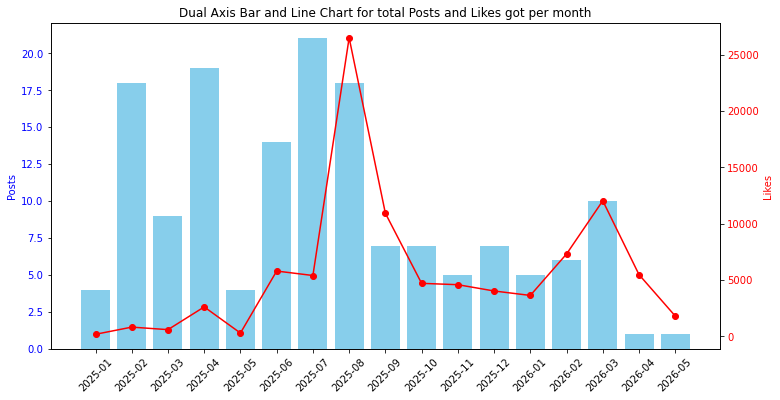

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot bars (total post per month) on the primary (left) y-axis
ax1.bar(df_monthly['Month'], df_monthly['nb_posts'], color='skyblue', label='Volume')
ax1.set_ylabel('Posts', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45)

# 2. Create a secondary y-axis sharing the same x-axis
ax2 = ax1.twinx()

# 3. Plot line on the secondary (right) y-axis
ax2.plot(df_monthly['Month'], df_monthly['total_likes'], color='red', marker='o', label='Likes')
ax2.set_ylabel('Likes', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Dual Axis Bar and Line Chart for total Posts and Likes got per month')
plt.savefig('outputs/monthly_growth.png', dpi=150, bbox_inches='tight')
plt.show()

### Identifiation des phases de croissance
- Phase 1: Janvier - Mai 2025: `Démarrage`
    Contenu non viral, avec une exploration sans stratégie claire. 

- Phase 2: Mai - Juillet 2025: `Montée` 
    Ici les likes commencent à décoller et sont corrélés au nombre de posts

- Phase 3: Août 2025 - Sept 2025: `Pic viral`
    Meilleures statistiques de tous les temps
    
- Phase 4: Oct 2025 - Jan 2026: `Stabilisation` 
    Constance sur le nombre de publications et les likes reçus
    
- Phase 5: Février - Mai 2026: `Maturation` 
    Le nombre de publications a réellement chuté mais l'influence reste solide. (A ne pas perdre)

In [44]:
print(type(df_videos['Month'][0]))

<class 'pandas._libs.tslibs.period.Period'>


In [41]:
print(df_videos.head())

                 Date  Likes WhoCanView AllowComments  \
0 2026-05-01 12:08:51   1814   Everyone           Yes   
1 2026-04-10 09:27:16   5489   Everyone           Yes   
2 2026-03-31 10:40:29    691   Everyone           Yes   
3 2026-03-30 20:57:53   1519   Everyone           Yes   
4 2026-03-26 10:59:18   1282   Everyone           Yes   

                               Sound    Month DayOfWeek  Hour  Quarter  \
0       original sound - amul_xalaat  2026-05    Friday    12        2   
1       original sound - amul_xalaat  2026-04    Friday     9        2   
2  Guitarra espaniola - Ashraf Ziada  2026-03   Tuesday    10        1   
3  Guitarra espaniola - Ashraf Ziada  2026-03    Monday    20        1   
4  Guitarra espaniola - Ashraf Ziada  2026-03  Thursday    10        1   

        SoundType  
0        Original  
1        Original  
2  trending/music  
3  trending/music  
4  trending/music  


In [48]:
conditions = [
    df_videos['Month'].between('2025-01', '2025-05'),
    df_videos['Month'].between('2025-06', '2025-07'),
    df_videos['Month'].between('2025-08', '2025-09'),
    df_videos['Month'].between('2025-10', '2026-01'),
    df_videos['Month'].between('2026-02', '2026-05')
]
choices = ['Démarrage', 'Montée', 'Pic viral', 'Stabilisation', 'Maturation']
df_videos['Phases'] = np.select(conditions, choices, default='Unknown')


In [49]:
print(df_videos)

                   Date  Likes WhoCanView AllowComments  \
0   2026-05-01 12:08:51   1814   Everyone           Yes   
1   2026-04-10 09:27:16   5489   Everyone           Yes   
2   2026-03-31 10:40:29    691   Everyone           Yes   
3   2026-03-30 20:57:53   1519   Everyone           Yes   
4   2026-03-26 10:59:18   1282   Everyone           Yes   
..                  ...    ...        ...           ...   
151 2025-02-03 13:16:54     74   Everyone           Yes   
152 2025-01-26 20:55:33     68   Everyone           Yes   
153 2025-01-25 17:32:28     32   Everyone           Yes   
154 2025-01-24 20:51:12     55   Everyone           Yes   
155 2025-01-23 18:00:11     38   Everyone           Yes   

                                           Sound    Month DayOfWeek  Hour  \
0                   original sound - amul_xalaat  2026-05    Friday    12   
1                   original sound - amul_xalaat  2026-04    Friday     9   
2              Guitarra espaniola - Ashraf Ziada  2026-03   

In [50]:
df_videos['Phases'].value_counts()

Démarrage        54
Montée           35
Pic viral        25
Stabilisation    24
Maturation       18
Name: Phases, dtype: int64

In [51]:
df_videos.to_csv('data/processed/videos.csv', mode='w', index=False)

In [53]:
# Agrégation de la moyenne des likes par phases
df_monthly_phase  = df_videos.groupby('Phases').agg(
    nb_posts = ('Date', 'count'),
    total_likes = ('Likes', 'sum'),
    moyenne_likes = ('Likes', 'mean'),
).reset_index()

In [54]:
df_monthly_phase

,Phases,nb_posts,total_likes,moyenne_likes
0,Démarrage,54,4556,84.370370
1,Maturation,18,26671,1481.722222
2,Montée,35,11219,320.542857
3,Pic viral,25,37452,1498.080000
4,Stabilisation,24,16993,708.041667


In [57]:
df_monthly_phase = df_monthly_phase.set_index('Phases').loc[['Démarrage', 'Montée', 'Pic viral', 'Stabilisation', 'Maturation']]

In [64]:
df_monthly_phase


,nb_posts,total_likes,moyenne_likes
Phases,,,
Démarrage,54,4556,84.370370
Montée,35,11219,320.542857
Pic viral,25,37452,1498.080000
Stabilisation,24,16993,708.041667
Maturation,18,26671,1481.722222


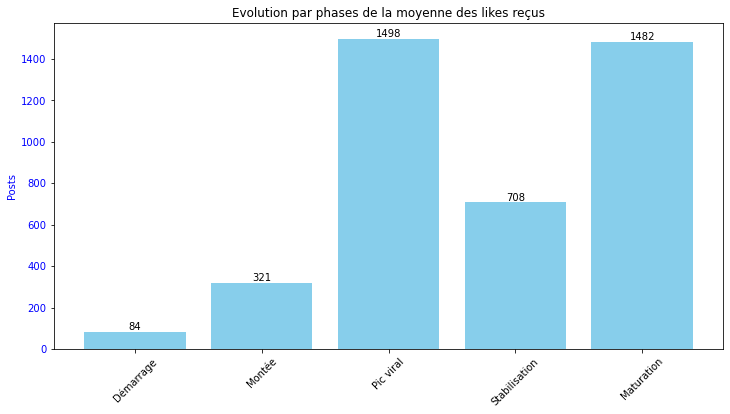

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))
# 1. Plot bars (total post per month) on the primary (left) y-axis
bars = ax.bar(df_monthly_phase.index, df_monthly_phase['moyenne_likes'], color='skyblue', label='Volume')
ax.set_ylabel('Posts', color='blue')
ax.tick_params(axis='y', labelcolor='blue')
# Add the labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            round(bar.get_height()), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title('Evolution par phases de la moyenne des likes reçus')
plt.show()